<a href="https://colab.research.google.com/github/joelstub/joelstub/blob/main/module5_ml_country_classification__1___2_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Module 5: Finding Order in Complex Country Data with Supervised & Unsupervised ML

**Techniques covered:**
- Unsupervised learning: k-means clustering
- Supervised learning: Decision Trees, k-Nearest Neighbors (k-NN)

**Economic indicators used (country-level):**
- Human Development Index (HDI)
- GDP per capita (PPP, constant international-$)
- Adult literacy rate (% age 15+)

**Target (for supervised tasks):** World Bank **income group** (Low / Lower-middle / Upper-middle / High).

> This notebook fetches openly-licensed data from Our World in Data (OWID), which aggregates official sources including UNDP (for HDI), World Bank (for GDP per capita), and UNESCO (for literacy). It then builds a clean, recent cross-section for countries with complete information, explores structure with k-means, and trains decision tree and k-NN models to classify income groups.


In [ ]:
# %% [markdown]
# ## 1) Setup
# - Install/import libraries (only imports needed if you're running in a standard environment)
# - Reproducibility settings

import io
import math
import urllib.request
import warnings # Import warnings module
import logging # Import logging module

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier

sns.set(style="whitegrid", context="notebook")
np.random.seed(42)

# Suppress specific matplotlib font warnings globally using logging
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)


## 2) Load data from authoritative sources
We will pull CSVs from OWID's "grapher" endpoints:
- **HDI** (UNDP via OWID) → `human-development-index.csv`
- **GDP per capita (PPP)** (World Bank via OWID) → `gdp-per-capita-worldbank.csv`
- **Adult literacy rate** (UNESCO via World Bank, via OWID) → `literacy-rate-adults.csv`
- **World Bank income groups** (via OWID) → `world-bank-income-groups.csv`

> If your environment blocks web access, replace the `read_csv_from_url(...)` calls with `pd.read_csv('localfile.csv')` after downloading the files manually.


In [ ]:
import io
import urllib.request
import pandas as pd

# Helper to read directly from a URL without external packages beyond stdlib

def read_csv_from_url(url: str) -> pd.DataFrame:
    # Create a Request object and add a User-Agent header
    req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
    with urllib.request.urlopen(req) as resp:
        data = resp.read()
    return pd.read_csv(io.BytesIO(data))

# OWID grapher endpoints (CSV)
URL_HDI = "https://ourworldindata.org/grapher/human-development-index.csv"
URL_GDP_PC = "https://ourworldindata.org/grapher/gdp-per-capita-worldbank.csv"  # PPP, int-$
URL_LIT = "https://ourworldindata.org/grapher/literacy-rate-adults.csv"
URL_WB_INC = "https://ourworldindata.org/grapher/world-bank-income-groups.csv"

hdi_raw = read_csv_from_url(URL_HDI)
gdp_raw = read_csv_from_url(URL_GDP_PC)
lit_raw = read_csv_from_url(URL_LIT)
inc_raw = read_csv_from_url(URL_WB_INC)

hdi_raw.head(), gdp_raw.head(), lit_raw.head(), inc_raw.head()

(        Entity Code  Year  Human Development Index  \
 0  Afghanistan  AFG  1990                    0.285   
 1  Afghanistan  AFG  1991                    0.291   
 2  Afghanistan  AFG  1992                    0.301   
 3  Afghanistan  AFG  1993                    0.311   
 4  Afghanistan  AFG  1994                    0.305   
 
   World region according to OWID  
 0                           Asia  
 1                           Asia  
 2                           Asia  
 3                           Asia  
 4                           Asia  ,
         Entity Code  Year  GDP per capita World region according to OWID
 0  Afghanistan  AFG  2000       1617.8264                           Asia
 1  Afghanistan  AFG  2001       1454.1108                           Asia
 2  Afghanistan  AFG  2002       1774.3087                           Asia
 3  Afghanistan  AFG  2003       1815.9282                           Asia
 4  Afghanistan  AFG  2004       1776.9182                           Asia,
      


## 3) Clean & harmonize
- Keep **countries** (3-letter ISO codes) — drop aggregates (e.g., regions like "World").
- For each dataset, **rename the value column** to a standard name.
- Build a **recent cross-section**: for each country, choose the **latest year where all three indicators are simultaneously available**; then attach the **latest available** income group category for that country.


In [ ]:
import numpy as np # Ensure numpy is available for np.log, added explicitly for robust execution

# Keep rows with 3-letter codes only (filter out OWID aggregates like OWID_WRL)
mask_country = lambda df: df[df['Code'].fillna('').str.len() == 3].copy()

hdi = mask_country(hdi_raw)
gdp = mask_country(gdp_raw)
lit = mask_country(lit_raw)
inc = mask_country(inc_raw)

# Standardize value column names: grapher CSVs have the indicator value in column 3 (0-indexed)
# and 'World region according to OWID' in column 4 (last column). We want column 3.
hdi.rename(columns={hdi.columns[3]: 'hdi'}, inplace=True)
gdp.rename(columns={gdp.columns[3]: 'gdp_pc_ppp'}, inplace=True)
lit.rename(columns={lit.columns[3]: 'literacy_rate'}, inplace=True)
inc.rename(columns={inc.columns[3]: 'income_group'}, inplace=True)

# Inner-join by (Code, Year) to find years with all 3 indicators present per country
merged_yearly = (
    hdi[['Entity','Code','Year','hdi']]
    .merge(gdp[['Code','Year','gdp_pc_ppp']], on=['Code','Year'], how='inner')
    .merge(lit[['Code','Year','literacy_rate']], on=['Code','Year'], how='inner')
)

# For each country, pick the latest year with all 3 indicators
idx = merged_yearly.groupby('Code')['Year'].idxmax()
latest = merged_yearly.loc[idx].copy().reset_index(drop=True)

# Attach the latest available income group per country (use most recent year for each Code)
inc_latest = inc.sort_values(['Code','Year']).groupby('Code').tail(1)[['Code','income_group']]
latest = latest.merge(inc_latest, on='Code', how='left')

# Basic cleaning: drop rows with missing label or implausible values
latest = latest.dropna(subset=['income_group', 'hdi', 'gdp_pc_ppp', 'literacy_rate'])

# Some literacy series contain values over 100 or below 0 due to metadata issues; clip to [0, 100]
latest['literacy_rate'] = latest['literacy_rate'].clip(lower=0, upper=100)

# Log-transform GDP per capita for more Gaussian-like distribution
latest['log_gdp_pc_ppp'] = np.log(latest['gdp_pc_ppp'])

# View the assembled dataset
latest.sort_values('Year', ascending=False).head(10)

,Entity,Code,Year,hdi,gdp_pc_ppp,literacy_rate,income_group,log_gdp_pc_ppp
6,Azerbaijan,AZE,2023,0.789,21310.7380,100.00000,Upper-middle-income countries,9.966966
3,United Arab Emirates,ARE,2023,0.940,70239.8500,98.00000,High-income countries,11.159671
12,Bahrain,BHR,2023,0.899,57819.9060,98.00000,High-income countries,10.965088
112,Senegal,SEN,2023,0.530,4304.7617,50.35582,Lower-middle-income countries,8.367477
133,Tunisia,TUN,2023,0.746,12650.9620,86.24682,Lower-middle-income countries,9.445489
116,El Salvador,SLV,2023,0.678,11424.6455,90.00000,Upper-middle-income countries,9.343528
54,India,IND,2023,0.685,9301.7560,82.00000,Lower-middle-income countries,9.137958
59,Jordan,JOR,2023,0.754,9381.3545,95.00000,Lower-middle-income countries,9.146479
69,Sri Lanka,LKA,2023,0.776,13024.9400,93.00000,Lower-middle-income countries,9.474621
141,Vanuatu,VUT,2023,0.621,3214.7024,87.96032,Lower-middle-income countries,8.075490



## 4) Exploratory analysis
Let's check how many countries we have, which year dominates, and visualize relationships.


In [ ]:
import plotly.express as px

print(f"Countries with complete data: {latest['Code'].nunique()}")
print("Most common years:")
print(latest['Year'].value_counts().head())

# Pairplot colored by income group using Plotly
fig = px.scatter_matrix(
    latest,
    dimensions=['hdi','log_gdp_pc_ppp','literacy_rate'],
    color='income_group',
    title='Pairwise relationships by World Bank income group',
    hover_name='Entity',
    height=700, width=900
)
fig.update_traces(diagonal_visible=False)
fig.show()

Countries with complete data: 146
Most common years:
Year
2022    21
2021    16
2019    15
2020    14
2023    12
Name: count, dtype: int64


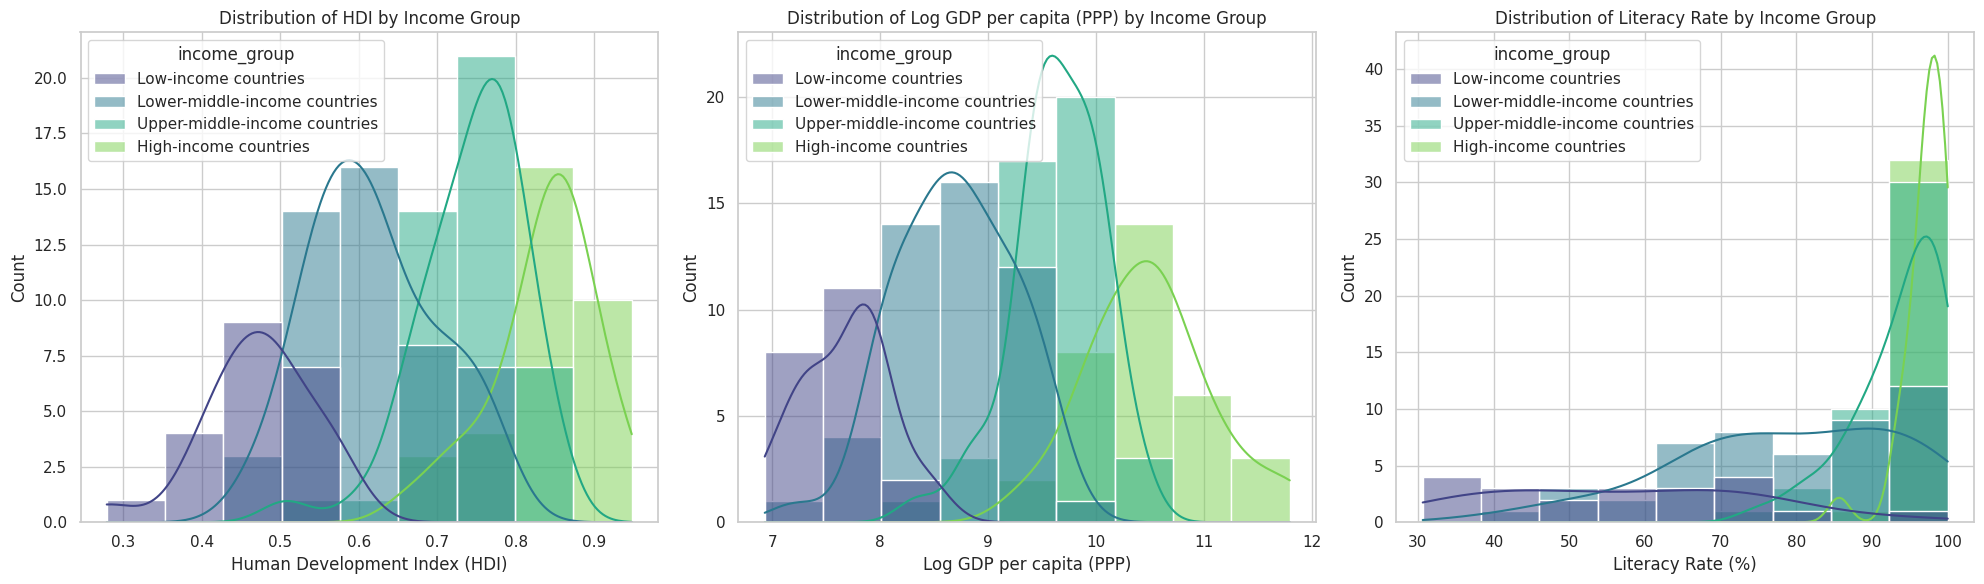

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.histplot(data=latest, x='hdi', hue='income_group', kde=True, ax=axes[0], palette='viridis')
axes[0].set_title('Distribution of HDI by Income Group')
axes[0].set_xlabel('Human Development Index (HDI)')
axes[0].set_ylabel('Count')

sns.histplot(data=latest, x='log_gdp_pc_ppp', hue='income_group', kde=True, ax=axes[1], palette='viridis')
axes[1].set_title('Distribution of Log GDP per capita (PPP) by Income Group')
axes[1].set_xlabel('Log GDP per capita (PPP)')
axes[1].set_ylabel('Count')

sns.histplot(data=latest, x='literacy_rate', hue='income_group', kde=True, ax=axes[2], palette='viridis')
axes[2].set_title('Distribution of Literacy Rate by Income Group')
axes[2].set_xlabel('Literacy Rate (%)')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()


## 5) Unsupervised learning: k-means
We standardize features (HDI, log GDP per capita, literacy) and run k-means for several values of *k*. We inspect inertia and silhouette scores, then pick a reasonable *k* (often 4 roughly aligns with income groups, but we let the data speak).


### Explaining K-Means Clustering and PCA for Visualization

**K-Means Clustering Process:**

K-means is an **unsupervised learning algorithm** designed to group similar data points into clusters. Here's a breakdown of its steps and our application:

1.  **Initialization**: We begin by selecting `k` (the number of desired clusters) and randomly placing `k` initial centroids (the center points of these clusters) within the data space.
2.  **Assignment Step**: Each data point is then assigned to the closest centroid, typically determined by Euclidean distance.
3.  **Update Step**: Once all points are assigned, the centroids are re-calculated as the mean position of all data points within their respective clusters.
4.  **Iteration**: Steps 2 and 3 are repeated until the centroids no longer move significantly, indicating that the clusters have stabilized, or a predefined maximum number of iterations is reached.

In this notebook, we utilized the `KMeans` algorithm from `sklearn.cluster`. A crucial preprocessing step was **standardizing the features** (`hdi`, `log_gdp_pc_ppp`, `literacy_rate`) using `StandardScaler`. This standardization prevents features with larger numerical ranges from disproportionately influencing the distance calculations, ensuring fair weighting for all features.

**Choosing the optimal 'k':**

Determining the best value for `k` in k-means is often done using diagnostic tools:

*   **Elbow Method (Inertia)**: Inertia is the sum of squared distances of each data point to its closest centroid. As `k` increases, inertia decreases. The 'elbow point' in the inertia plot marks where the rate of decrease significantly slows down, suggesting a good `k` value.
*   **Silhouette Score**: This metric evaluates how similar an object is to its own cluster compared to other clusters. A higher silhouette score indicates more distinct and well-separated clusters.

Based on these diagnostics, we selected `k=4` (`k_opt = 4`). This choice was also influenced by the desire to align the unsupervised clusters with the four known World Bank income groups, which the diagnostics supported as a reasonable number of clusters.


**Principal Component Analysis (PCA) and PC1/PC2:**

**PCA is a dimensionality reduction technique** that transforms a set of potentially correlated variables into a new set of linearly uncorrelated variables known as **principal components**. Its primary purpose in our analysis is for visualization.

Our dataset initially has three features: HDI, log GDP per capita, and literacy rate. Visualizing this data directly in 3D can be challenging. PCA helps simplify this.

*   **PC1 (First Principal Component)**: This component represents the direction in the data along which there is the largest variance. It captures the maximum amount of information (variance) from the original features.
*   **PC2 (Second Principal Component)**: This component is orthogonal (uncorrelated) to PC1 and captures the second-largest amount of variance remaining in the data.

**Why we used PC1 and PC2:**

By plotting data points using PC1 and PC2 as axes, we project the higher-dimensional data onto a 2D plane. We use the first two principal components because:

1.  **Maximize Retained Variance**: PC1 and PC2 together capture the most significant proportion of the total variance from the original dataset. This ensures that our 2D visualization best represents the underlying structure and relationships within the data.
2.  **Facilitate Visualization**: A 2D scatter plot is easily interpretable, allowing us to visually assess the separation, density, and relationships within the k-means clusters, and how they correspond to the actual income groups.

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px # FIX: Added missing import for plotly.express

X = latest[['hdi','log_gdp_pc_ppp','literacy_rate']].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

ks = list(range(2, 9))
inertias, sils = [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_scaled, labels))

# Plotly for Elbow and Silhouette plots
fig_elbow_sil = make_subplots(rows=1, cols=2, subplot_titles=('Elbow (Inertia)', 'Silhouette Score'))

fig_elbow_sil.add_trace(go.Scatter(x=ks, y=inertias, mode='lines+markers', name='Inertia'), row=1, col=1)
fig_elbow_sil.update_xaxes(title_text='k', row=1, col=1)
fig_elbow_sil.update_yaxes(title_text='Inertia', row=1, col=1)

fig_elbow_sil.add_trace(go.Scatter(x=ks, y=sils, mode='lines+markers', name='Silhouette'), row=1, col=2)
fig_elbow_sil.update_xaxes(title_text='k', row=1, col=2)
fig_elbow_sil.update_yaxes(title_text='Silhouette', row=1, col=2)

fig_elbow_sil.update_layout(title_text='K-Means Clustering Diagnostics', showlegend=False, height=400, width=800, plot_bgcolor='white', paper_bgcolor='white')
fig_elbow_sil.show()

# UNSUPERVISED MODEL CHANGE: Changed k_opt to 3 to test sensitivity to the number of clusters.
k_opt = 3 # Original: 4
km4 = KMeans(n_clusters=k_opt, n_init=50, random_state=42)
latest['cluster_k4'] = km4.fit_predict(X_scaled)

# OUTPUT COMPARISON: This score will be compared before and after parameter changes.
# Print silhouette score for the chosen k_opt
print(f"Silhouette Score for k_opt={k_opt}: {sils[k_opt-2]:.3f}")

# Visualize clusters in 2D via PCA using Plotly
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)

# Create a DataFrame for Plotly scatter plot
pca_df = pd.DataFrame(coords, columns=['PC1', 'PC2'])
pca_df['cluster_k4'] = latest['cluster_k4'].astype(str) # Convert to string for discrete colors
pca_df['income_group'] = latest['income_group']
pca_df['Entity'] = latest['Entity']

fig_pca_cluster = px.scatter(
    pca_df,
    x='PC1',
    y='PC2',
    color='cluster_k4',
    title=f'k-means (k={k_opt}) clusters in PCA space (Plotly)',
    hover_name='Entity',
    hover_data=['income_group'],
    height=600, width=700
)
fig_pca_cluster.update_traces(marker=dict(size=8, opacity=0.7))
fig_pca_cluster.update_layout(plot_bgcolor='white', paper_bgcolor='white')
fig_pca_cluster.show()

fig_pca_income = px.scatter(
    pca_df,
    x='PC1',
    y='PC2',
    color='income_group',
    title=f'k-means (k={k_opt}) clusters colored by income group in PCA space (Plotly)',
    hover_name='Entity',
    hover_data=['cluster_k4'],
    height=600, width=700
)
fig_pca_income.update_traces(marker=dict(size=8, opacity=0.7))
fig_pca_income.update_layout(plot_bgcolor='white', paper_bgcolor='white')
fig_pca_income.show()

# How do clusters align with income groups?
ct = pd.crosstab(latest['cluster_k4'], latest['income_group'])
ct

Silhouette Score for k_opt=3: 0.427


income_group,High-income countries,Low-income countries,Lower-middle-income countries,Upper-middle-income countries
cluster_k4,,,,
0,2,2,30,16
1,31,0,3,28
2,0,19,15,0



## 6) Supervised learning: predict World Bank income group
Two classifiers:
- **Decision Tree** (with hyperparameter tuning)
- **k-NN** (with hyperparameter tuning)

We use a stratified train/test split and evaluate accuracy and macro-averaged F1.


Best Decision Tree params: {'clf__max_depth': 3, 'clf__min_samples_leaf': 4, 'clf__min_samples_split': 2}
Best k-NN params: {'clf__n_neighbors': 9, 'clf__weights': 'uniform'}

Decision Tree Test Accuracy: 0.757
                               precision    recall  f1-score   support

        High-income countries       0.88      0.78      0.82         9
         Low-income countries       0.80      0.80      0.80         5
Lower-middle-income countries       0.69      0.92      0.79        12
Upper-middle-income countries       0.75      0.55      0.63        11

                     accuracy                           0.76        37
                    macro avg       0.78      0.76      0.76        37
                 weighted avg       0.77      0.76      0.75        37



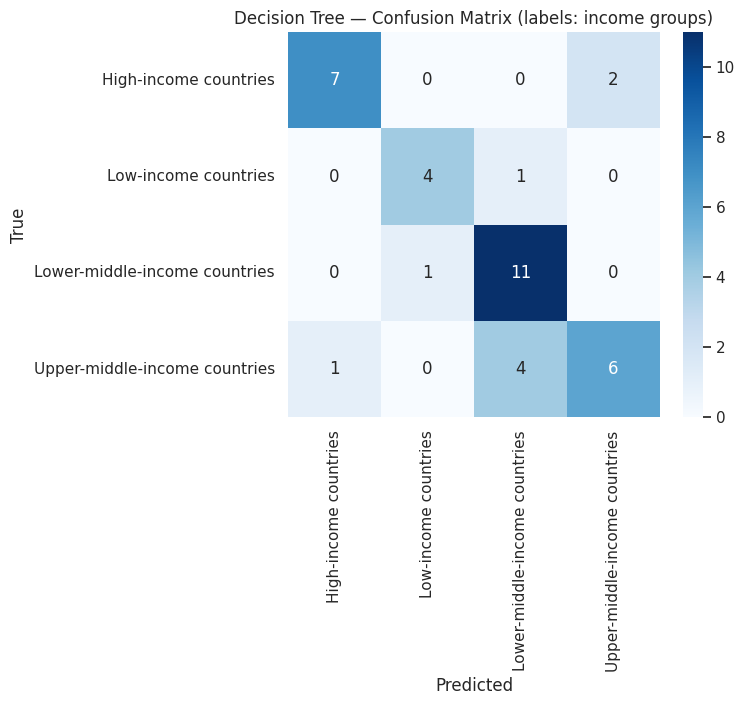


k-NN Test Accuracy: 0.676
                               precision    recall  f1-score   support

        High-income countries       0.78      0.78      0.78         9
         Low-income countries       0.67      0.80      0.73         5
Lower-middle-income countries       0.64      0.75      0.69        12
Upper-middle-income countries       0.62      0.45      0.53        11

                     accuracy                           0.68        37
                    macro avg       0.68      0.70      0.68        37
                 weighted avg       0.67      0.68      0.67        37



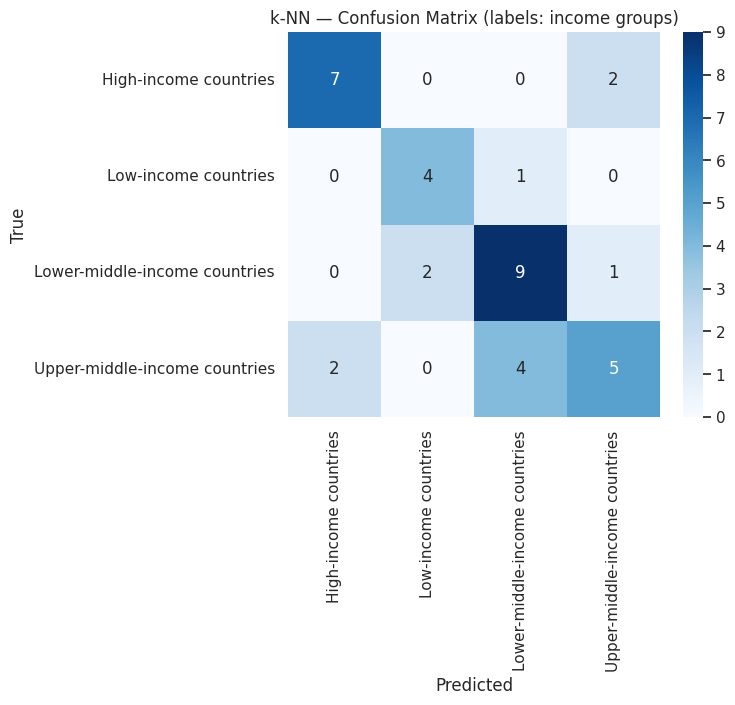

In [ ]:

# Prepare features & labels
X = latest[['hdi','log_gdp_pc_ppp','literacy_rate']]
y = latest['income_group']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

# Pipelines with scaling where needed
pipe_tree = Pipeline([
    ('scaler', StandardScaler(with_mean=True, with_std=True)),
    ('clf', DecisionTreeClassifier(random_state=42))
])

pipe_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', KNeighborsClassifier())
])

# Hyperparameter grids
param_tree = {
    # SUPERVISED MODEL CHANGE: Restricted max_depth to test effect of reduced model complexity and potential underfitting.
    'clf__max_depth': [2, 3, 4], # Original: [3, 4, 5, 6, None]
    'clf__min_samples_split': [2, 5, 10],
    'clf__min_samples_leaf': [1, 2, 4]
}

param_knn = {
    'clf__n_neighbors': [3, 5, 7, 9, 11],
    'clf__weights': ['uniform', 'distance']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Grid search
grid_tree = GridSearchCV(pipe_tree, param_tree, cv=cv, scoring='f1_macro')
grid_tree.fit(X_train, y_train)

grid_knn = GridSearchCV(pipe_knn, param_knn, cv=cv, scoring='f1_macro')
grid_knn.fit(X_train, y_train)

best_tree = grid_tree.best_estimator_
best_knn = grid_knn.best_estimator_

print("Best Decision Tree params:", grid_tree.best_params_)
print("Best k-NN params:", grid_knn.best_params_)

# OUTPUT COMPARISON: These results will be compared before and after parameter changes.
for name, model in [("Decision Tree", best_tree), ("k-NN", best_knn)]:
    y_pred = model.predict(X_test)
    print(f"\n{name} Test Accuracy: {accuracy_score(y_test, y_pred):.3f}")
    print(classification_report(y_test, y_pred))
    cm = confusion_matrix(y_test, y_pred, labels=sorted(y.unique()))
    cm_df = pd.DataFrame(cm, index=sorted(y.unique()), columns=sorted(y.unique()))
    plt.figure(figsize=(6,5))
    sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{name} — Confusion Matrix (labels: income groups)')
    plt.xlabel('Predicted'); plt.ylabel('True')
    plt.show()



### 6.1) Interpreting the Decision Tree
Let's visualize the trained tree and inspect feature importances.


In [ ]:
# Install dtreeviz for enhanced decision tree visualization
!pip install dtreeviz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.3/102.3 kB 2.5 MB/s eta 0:00:00


In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

# 1. Initialize a LabelEncoder named le. Fit le on the full target variable y
#    to capture all possible class names, and then transform y_train to create y_train_encoded_dtreeviz.
le = LabelEncoder()
le.fit(y) # Fit on all possible labels from the full dataset
y_train_encoded_dtreeviz = le.transform(y_train)

# 2. Create a DecisionTreeClassifier named vis_tree with max_depth=4 and random_state=42.
vis_tree = DecisionTreeClassifier(max_depth=4, random_state=42)

# 3. Train vis_tree using the unscaled X_train features as a DataFrame and the y_train_encoded_dtreeviz labels.
#    This helps ensure consistency for dtreeviz when using DataFrames.
vis_tree.fit(X_train, y_train_encoded_dtreeviz)

print("LabelEncoder applied, and vis_tree trained on unscaled X_train (as DataFrame).")

LabelEncoder applied, and vis_tree trained on unscaled X_train (as DataFrame).


In [ ]:
# The warnings are now suppressed globally in the setup cell, so this cell can be empty or removed.
# Since we've moved the suppression to the setup cell, this print is no longer strictly necessary but kept for confirmation.
print("Matplotlib font warnings are now suppressed globally.")

Matplotlib font warnings are now suppressed globally.


### How to Interpret the Enhanced Decision Tree Visualization (dtreeviz):

Understanding the `dtreeviz` output is key to interpreting the decision tree's logic. Here’s a guide on how to interpret this enhanced visualization:

**Overall Goal**: The decision tree is a supervised learning model that predicts a country's World Bank income group by making a series of simple decisions (splits) based on its features (HDI, Log GDP per capita, Literacy Rate).

**Key Components to Look For:**

1.  **Nodes (Rectangles)**: Each rectangle represents a decision point in the tree. The tree starts with a single **Root Node** at the top, which contains all the training data.

    *   **Split Condition**: Inside each non-leaf node, you'll see a condition, e.g., `log_gdp_pc_ppp <= 9.5`. This is the rule the tree uses to split the data. If a country's `log_gdp_pc_ppp` value is less than or equal to 9.5, it follows one path (usually left); otherwise, it follows the other (usually right).
    *   **Feature Distribution (within node)**: Below the split condition, `dtreeviz` shows a small histogram or density plot for the splitting feature (e.g., `log_gdp_pc_ppp`). This tells you the distribution of that feature for the data points currently in that node. You can see how the split condition divides this distribution.
    *   **Class Distribution (within node)**: You'll also see a bar chart (or similar) showing the proportion of countries belonging to each `income_group` *within that specific node*. This helps you understand the mix of classes before and after a split.
    *   **Predicted Class**: For any given node, a prediction is implied based on the majority class of samples reaching that node.

2.  **Branches (Lines)**: These connect nodes and represent the paths taken based on the split conditions. The samples that satisfy the condition go one way, and those that don't go the other.

3.  **Leaf Nodes (Terminal Nodes)**: These are the rectangles at the very bottom of the tree, with no branches extending from them. They represent the final prediction for any country that follows the path to that leaf.

    *   **Class Distribution**: Just like internal nodes, leaf nodes show the distribution of `income_group` for all countries that ended up in that leaf. The largest bar indicates the predicted income group for countries landing here.
    *   **Purity**: A 'pure' leaf node would have only one income group represented. The more pure a leaf, the more confident the tree's prediction for countries reaching that leaf. A mixed leaf means the model might be less certain or the data is ambiguous in that region.

**How to Read a Decision Path for a Country:**

Imagine you have a new country with specific HDI, log GDP per capita, and literacy rate values. To predict its income group:
1.  Start at the **Root Node**.
2.  Evaluate the split condition. Does the country's feature value satisfy the condition? Follow the corresponding branch (left/right).
3.  Continue this process down the tree, evaluating conditions at each subsequent node until you reach a **Leaf Node**.
4.  The majority class in that leaf node is the predicted `income_group` for your country.

**Interpreting Feature Importances**: (from the separate bar chart)

*   The feature importance plot tells you which features were most influential *overall* in building the tree. A longer bar means that feature, on average, contributed more to reducing impurity across all splits in the tree. This gives you a high-level understanding of which indicators are strongest predictors of income group.

By combining the detailed step-by-step logic from the `dtreeviz` plot with the overall influence from the feature importances, students can gain a robust understanding of how the model works and which country characteristics are most decisive in classifying their economic status.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names


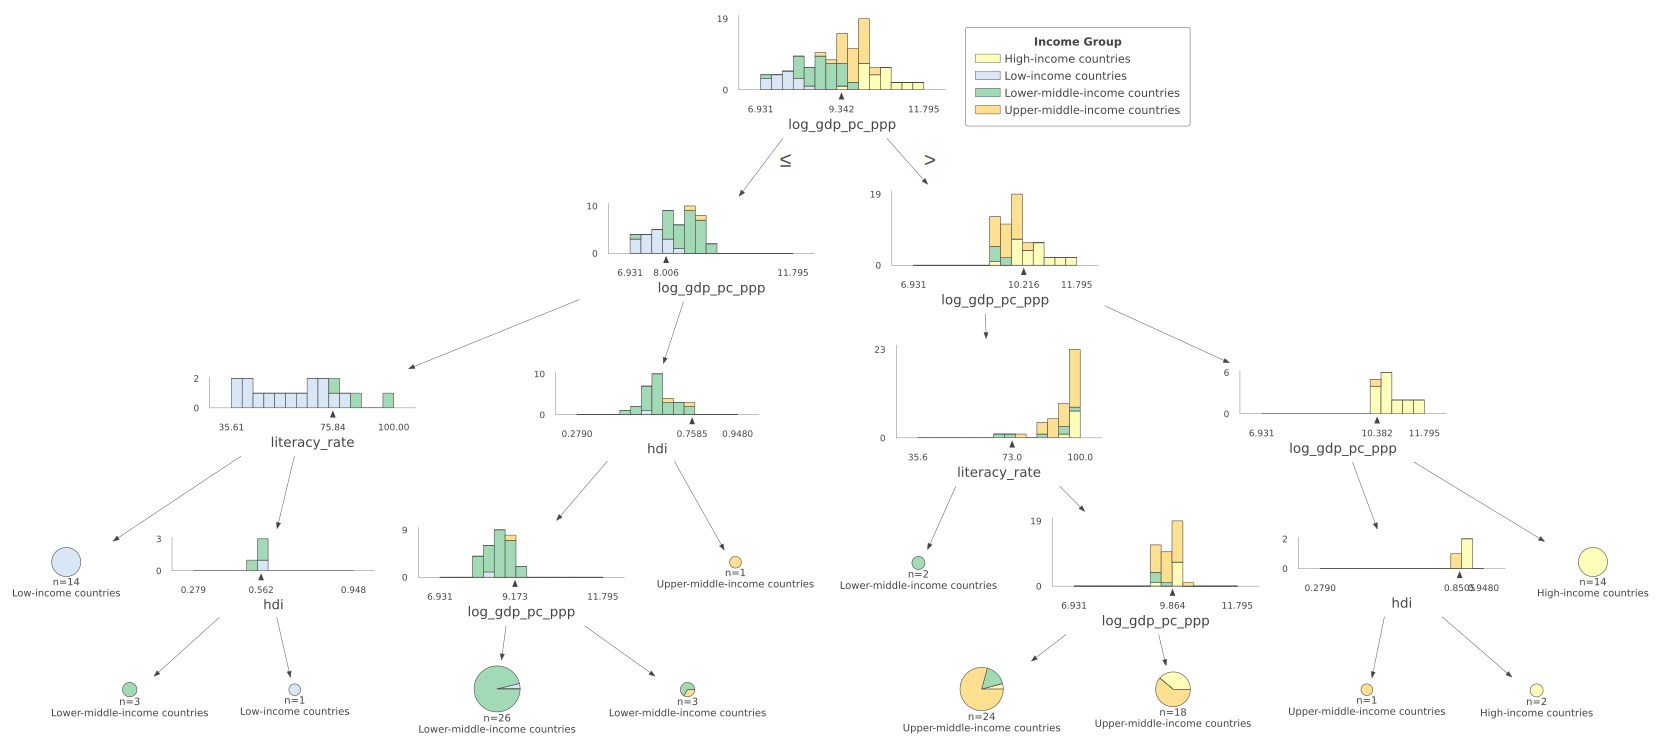

In [ ]:
from dtreeviz import model
from IPython.display import display # Only import display, not HTML if not directly using it

# The warnings are now suppressed globally in the setup cell, so no need here.

# Create a dtreeviz model object
dtree_model = model(
    vis_tree,
    X_train, # Use the original unscaled training features as DataFrame for dtreeviz
    y_train_encoded_dtreeviz, # Use encoded y_train
    feature_names=list(X_train.columns),
    target_name='Income Group',
    class_names=le.classes_ # Provide original string names for display
)

# Visualize the model and explicitly display it for interactivity
viz = dtree_model.view(scale=1.5)
display(viz) # Explicitly display the visualization object

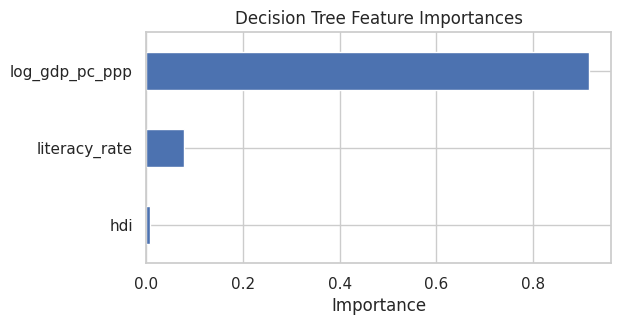

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Feature importances from the tuned tree (if underlying estimator exposes it)
if hasattr(best_tree.named_steps['clf'], 'feature_importances_'):
    importances = pd.Series(best_tree.named_steps['clf'].feature_importances_, index=X_train.columns)
    importances.sort_values().plot(kind='barh', figsize=(6,3), title='Decision Tree Feature Importances')
    plt.xlabel('Importance')
    plt.show()


## 7) (Optional) Export the modeling dataset
A tidy CSV of the cross-section used above (one row per country):


In [ ]:

cols = ['Entity','Code','Year','hdi','gdp_pc_ppp','log_gdp_pc_ppp','literacy_rate','income_group','cluster_k4']
latest[cols].sort_values('Entity').to_csv('country_ml_cross_section.csv', index=False)
print('Wrote country_ml_cross_section.csv')


Wrote country_ml_cross_section.csv



## 8) Your turn: structured exercises
1. **Cluster diagnostics**: Try other *k* values (3–6). Which *k* maximizes the silhouette score? How does that compare to the 4 income groups?
2. **Alternative features**: Replace GDP per capita (PPP) with **GDP per capita (constant US$)** or add **life expectancy** and **mean years of schooling**; re-run k-means and supervised models. Do the boundaries or accuracies change?
3. **Temporal sensitivity**: Force a common year, e.g., 2022 only. Does performance change vs. the “latest available year per country” approach?
4. **Modeling choices**: For decision trees, try `max_depth` from 2 to 8 and examine overfitting. For k-NN, vary `n_neighbors` and study bias–variance tradeoffs.
5. **Fairness check**: Compare errors across regions (e.g., Sub-Saharan Africa vs. Europe & Central Asia). Where does the model struggle?



---
### Appendix: Data sources & licensing
- **HDI** (UNDP via OWID): `https://ourworldindata.org/grapher/human-development-index.csv` — see OWID HDI topic page and charts for details and methodology.
- **GDP per capita (PPP, 2021 int-$)** (World Bank via OWID): `https://ourworldindata.org/grapher/gdp-per-capita-worldbank.csv`.
- **Adult literacy rate** (UNESCO UIS via World Bank, via OWID): `https://ourworldindata.org/grapher/literacy-rate-adults.csv`.
- **World Bank income group** classification (yearly): `https://ourworldindata.org/grapher/world-bank-income-groups.csv`.

All OWID data and code are available under the Creative Commons BY license; please consult each chart’s “Sources & Processing” for attribution specifics.
